In [1]:
import pandas as pd
import nltk

In [2]:
df=pd.read_csv("../flipkart.csv")
df

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5
...,...,...
9971,GoodREAD MORE,5
9972,Everything is amazimg but the built is very li...,5
9973,GoodREAD MORE,5
9974,Best headphone i have ever used....READ MORE,5


In [3]:
df=df.drop("rating",axis=1)
df

,review
0,It was nice produt. I like it's design a lot. ...
1,awesome sound....very pretty to see this nd th...
2,awesome sound quality. pros 7-8 hrs of battery...
3,I think it is such a good product not only as ...
4,awesome bass sound quality very good bettary l...
...,...
9971,GoodREAD MORE
9972,Everything is amazimg but the built is very li...
9973,GoodREAD MORE
9974,Best headphone i have ever used....READ MORE


In [4]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [5]:
lemmatizer=WordNetLemmatizer()

In [6]:
stop_words = set(stopwords.words('english'))

def preprocess_review(text):
    if pd.isna(text):
        return ""

    text = re.sub(r'<.*?>|[^a-zA-Z]', ' ', text).lower()

    return ' '.join(
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    )

In [7]:
df["clean_review"]=df["review"].apply(preprocess_review)

In [8]:
df

,review,clean_review
0,It was nice produt. I like it's design a lot. ...,nice produt like design lot easy carry looked ...
1,awesome sound....very pretty to see this nd th...,awesome sound pretty see nd sound quality good...
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pro hr battery life incl...
3,I think it is such a good product not only as ...,think good product per quality also design qui...
4,awesome bass sound quality very good bettary l...,awesome bass sound quality good bettary long l...
...,...,...
9971,GoodREAD MORE,goodread
9972,Everything is amazimg but the built is very li...,everything amazimg built light read
9973,GoodREAD MORE,goodread
9974,Best headphone i have ever used....READ MORE,best headphone ever used read


In [9]:
from textblob import TextBlob

def get_sentiment(text):
    polarity=TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"
df["predicted_sentiment"]=df["clean_review"].apply(get_sentiment)

In [10]:
df

,review,clean_review,predicted_sentiment
0,It was nice produt. I like it's design a lot. ...,nice produt like design lot easy carry looked ...,Positive
1,awesome sound....very pretty to see this nd th...,awesome sound pretty see nd sound quality good...,Positive
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pro hr battery life incl...,Positive
3,I think it is such a good product not only as ...,think good product per quality also design qui...,Positive
4,awesome bass sound quality very good bettary l...,awesome bass sound quality good bettary long l...,Positive
...,...,...,...
9971,GoodREAD MORE,goodread,Neutral
9972,Everything is amazimg but the built is very li...,everything amazimg built light read,Positive
9973,GoodREAD MORE,goodread,Neutral
9974,Best headphone i have ever used....READ MORE,best headphone ever used read,Positive


In [11]:
df["predicted_sentiment"].value_counts()

predicted_sentiment
Positive    7108
Neutral     2395
Negative     473
Name: count, dtype: int64

In [12]:
from rake_nltk import Rake
rake=Rake()

In [13]:
def extract_keywords(text,top_n=5):
    rake.extract_keywords_from_text(text)
    keywords=rake.get_ranked_phrases()
    return keywords[:top_n]

In [14]:
df["rake_keywords"]=df["clean_review"].apply(extract_keywords)

In [15]:
df

,review,clean_review,predicted_sentiment,rake_keywords
0,It was nice produt. I like it's design a lot. ...,nice produt like design lot easy carry looked ...,Positive,[nice produt like design lot easy carry looked...
1,awesome sound....very pretty to see this nd th...,awesome sound pretty see nd sound quality good...,Positive,[awesome sound pretty see nd sound quality goo...
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pro hr battery life incl...,Positive,[awesome sound quality pro hr battery life inc...
3,I think it is such a good product not only as ...,think good product per quality also design qui...,Positive,[think good product per quality also design qu...
4,awesome bass sound quality very good bettary l...,awesome bass sound quality good bettary long l...,Positive,[awesome bass sound quality good bettary long ...
...,...,...,...,...
9971,GoodREAD MORE,goodread,Neutral,[goodread]
9972,Everything is amazimg but the built is very li...,everything amazimg built light read,Positive,[everything amazimg built light read]
9973,GoodREAD MORE,goodread,Neutral,[goodread]
9974,Best headphone i have ever used....READ MORE,best headphone ever used read,Positive,[best headphone ever used read]


In [16]:
from collections import Counter
def top_preferences(sentiment,n=10):
    keywords=[]
    for kws in df[df["predicted_sentiment"]==sentiment]["rake_keywords"]:
        keywords.extend(kws)
    return Counter(keywords).most_common(n)

In [17]:
print("Positive Preferences :")
print(top_preferences("Positive"))

print("\n Negative Preferences :")
print(top_preferences("Negative"))

print("\n Neutral Preferences :")
print(top_preferences("Neutral"))

Positive Preferences :
[('nice productread', 203), ('good productread', 195), ('good product read', 63), ('nice read', 47), ('awesome read', 45), ('good read', 35), ('nice product read', 32), ('awesome productread', 30), ('good qualityread', 30), ('excellent productread', 26)]

 Negative Preferences :
[('bad read', 4), ('bass goodread', 4), ('bad productread', 3), ('average qualityread', 3), ('worst productread', 3), ('tight earsread', 2), ('gave star wear headphone run track min sweat come uncomfortable headphonesread', 2), ('average read', 2), ('awsome product purchased year still product comparison price range must buy bass lover read', 2), ('poor qualityread', 2)]

 Neutral Preferences :
[('goodread', 368), ('niceread', 252), ('superread', 82), ('awesomeread', 77), ('excellentread', 47), ('superbread', 37), ('okread', 33), ('bestread', 28), ('amazingread', 27), ('badread', 23)]


In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
def generate_wordcloud(keywords,title):
    text=" ".join(keywords)

    wc=WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure()
    plt.imshow(wc,interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()
    

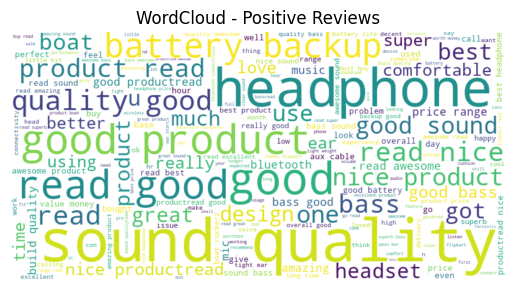

In [24]:
positive_keywords=[]
for kws in df[df["predicted_sentiment"]=="Positive"]["rake_keywords"]:
    positive_keywords.extend(kws)
generate_wordcloud(positive_keywords,"WordCloud - Positive Reviews")